In [1]:
!nvidia-smi

Thu May 14 03:57:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 PCIe               On  |   00000000:01:00.0 Off |                    0 |
| N/A   34C    P0             79W /  350W |   48271MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# Выбрать GPU с минимальной занятой памятью
import subprocess
import os

def get_free_gpu():
    result = subprocess.check_output(
        ["nvidia-smi", "--query-gpu=memory.used", "--format=csv,nounits,noheader"]
    )
    memory = [int(x) for x in result.decode().strip().split("\n")]
    return memory.index(min(memory)), min(memory)

gpu_id, memory_used = get_free_gpu()
os.environ["CUDA_VISIBLE_DEVICES"] = str(gpu_id)

print(f"Using GPU {gpu_id} (memory usage: {memory_used}MiB)")

Using GPU 4 (memory usage: 4MiB)


In [3]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "5"

In [3]:
path = "/var/essdata/DN_1/storage/home/ttn/data/swe_trajectories/nemotron"

https://unsloth.ai/docs/basics/chat-templates#applying-chat-templates-with-unsloth

In [11]:
from unsloth.chat_templates import CHAT_TEMPLATES
print(list(CHAT_TEMPLATES.keys()))

['unsloth', 'zephyr', 'chatml', 'mistral', 'llama', 'vicuna', 'vicuna_old', 'vicuna old', 'alpaca', 'gemma', 'gemma_chatml', 'gemma2', 'gemma2_chatml', 'llama-3', 'llama3', 'phi-3', 'phi-35', 'phi-3.5', 'llama-3.1', 'llama-31', 'llama-3.2', 'llama-3.3', 'llama-32', 'llama-33', 'qwen-2.5', 'qwen-25', 'qwen25', 'qwen2.5', 'phi-4', 'gemma-3', 'gemma3', 'qwen-3', 'qwen3', 'gemma-3n', 'gemma3n', 'gpt-oss', 'gptoss', 'qwen3-instruct', 'qwen3-thinking', 'lfm-2', 'starling', 'yi-chat']


In [14]:
print(CHAT_TEMPLATES['qwen3'][0]) # это вот те преобразования, которые сделает tokenizer.apply_chat_template() (см. ниже)


{%- if tools %}
    {{- '<|im_start|>system
' }}
    {%- if messages[0].role == 'system' %}
        {{- messages[0].content + '

' }}
    {%- endif %}
    {{- "# Tools

You may call one or more functions to assist with the user query.

You are provided with function signatures within <tools></tools> XML tags:
<tools>" }}
    {%- for tool in tools %}
        {{- "
" }}
        {{- tool | tojson }}
    {%- endfor %}
    {{- "
</tools>

For each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:
<tool_call>
{\"name\": <function-name>, \"arguments\": <args-json-object>}
</tool_call><|im_end|>
" }}
{%- else %}
    {%- if messages[0].role == 'system' %}
        {{- '<|im_start|>system
' + messages[0].content + '<|im_end|>
' }}
    {%- endif %}
{%- endif %}
{%- set ns = namespace(multi_step_tool=true, last_query_index=messages|length - 1) %}
{%- for forward_message in messages %}
    {%- set index = (messages|length - 1) - loop.index

In [20]:
CHAT_TEMPLATES['qwen-3']==CHAT_TEMPLATES['qwen3']

True

Лучше перевести датасет в формат `prompt`/`completion`: тогда `prompt` содержит system + user + предыдущие сообщения окна, а `completion` — только текущий `assistant`:
1. режем каждую траекторию на чанки по каждому `assistant`-сообщению,
2. в `prompt` кладём `system + first user + последние 10 сообщений до текущего assistant`,
3. в `completion` кладём только текущий `assistant`,

Разбиение на чанки идейно близко к этому (https://arxiv.org/pdf/2602.17547):

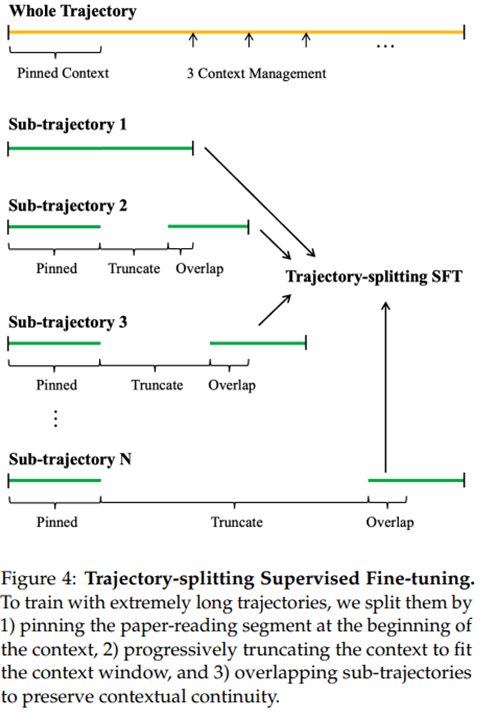
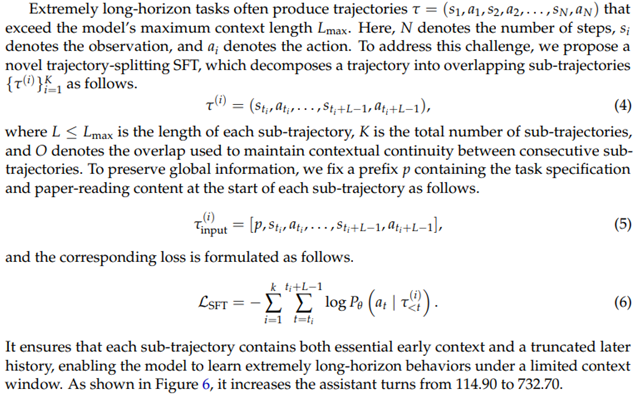

In [3]:
from datasets import load_from_disk
from transformers import AutoTokenizer
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig
import json
import torch
import random
from collections import defaultdict

path = "/var/essdata/DN_1/storage/home/ttn/data/swe_trajectories/nemotron"
MODEL_PATH = "/var/essdata/DN_1/storage/home/ttn/models/Qwen3-4B"
OUTPUT_PATH = "/var/essdata/DN_1/storage/home/ttn/models/qwen3-4b-swe-lora/ft_on_nemotron/chunked_trajectories"

MAX_SEQ_LENGTH = 16384 # 2 ** 14 
# (прим.: изначально пробовали 30000, но по статистикам и гистограмме поняли, что это слишком много,
# т.к. там получался 95 percentile всего 11397.
# Поэтому при 30000 из-за большого паддинга для многих чанков долго дообучалась модель.
# Поэтому решили сократить до 2 ** 14 = 16384)
WINDOW_SIZE = 10

#ds = load_from_disk(path)["r2e_gym"]

train_raw = load_from_disk("/var/essdata/DN_1/storage/home/ttn/data/swe_trajectories/nemotron_train_raw")
test_raw = load_from_disk("/var/essdata/DN_1/storage/home/ttn/data/swe_trajectories/nemotron_test_raw")

print(len(train_raw), len(test_raw))
print(len(set(train_raw["uuid"])), len(set(test_raw["uuid"])))


def normalize_message(msg):
    role = msg["role"]
    content = msg.get("content") or ""

    if role != "assistant":
        # system / user / tool оставляем как есть
        return {
            "role": role,
            "content": content,
            **({"id": msg["id"]} if msg.get("id") is not None else {}),
        }

    reasoning = None
    tool_calls = []

    # тут цикл для надёжности, но вообще в msg["tool_calls"] только один call
    for call in msg.get("tool_calls") or []:
        name = call["function"]["name"]
        args = call["function"].get("arguments", "")

        if name == "think":
            try:
                reasoning = json.loads(args).get("thought", args)
            except Exception:
                reasoning = args
        else:
            tool_calls.append(call)

    out = {
        "role": "assistant",
        "content": content,
    }

    if reasoning is not None:
        out["reasoning_content"] = reasoning
        # так think будет корректно обработан .apply_chat_template()
        # а именно: reasoning будет ПЕРЕД content
        # и это правильно, т.к. в данном даттасете действительно сначала assistant размышляет,
        # а затем на основе своих мыслей делает вывод о том, что он будет делать.
        # пример: <|im_start|>assistant\n<think>\nLet me analyze the problem clearly:...
        # \n</think>\n\nPerfect! I\'ve confirmed the issue. The script shows that:...

    if tool_calls:
        out["tool_calls"] = tool_calls

    return out


def build_chunked_examples(batch):
    prompts = []
    completions = []

    for raw_messages in batch["messages"]:
        msgs = [normalize_message(m) for m in raw_messages]

        if len(msgs) < 3:
            continue

        system_msg = msgs[0]
        first_user_msg = msgs[1]
        body = msgs[2:]

        # все assistant-ответы в траектории
        assistant_indices = [i for i, m in enumerate(body) if m["role"] == "assistant"]

        for i in assistant_indices:
            completion = [body[i]]
            left_ctx = body[:i]

            # сначала берём WINDOW_SIZE, потом при необходимости сокращаем
            k = min(WINDOW_SIZE, len(left_ctx))
            while k >= 0:
                # берём контекст из системного промпта, юзерного промпта и k сообщений,
                # идущих до текущего целевого ответа assistant
                prompt = [system_msg, first_user_msg, *left_ctx[-k:]]
                full_messages = prompt + completion

                text = tokenizer.apply_chat_template(
                    full_messages,
                    tokenize=False,
                    add_generation_prompt=False,
                )
                n_tokens = len(tokenizer(text, add_special_tokens=False).input_ids)

                if n_tokens <= MAX_SEQ_LENGTH:
                    prompts.append(prompt)
                    completions.append(completion)
                    break

                # если n_tokens > MAX_SEQ_LENGTH, 
                # то со следующей итерации сокращаем контекст на 1 сообщение слева 
                # (т.е. самое старое сообщение, не считая system и prompt)
                k -= 1

            # если даже system+user+completion не влезает, этот пример пропускаем

    return {"prompt": prompts, "completion": completions}

# load tokenizer for length filtering
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

# expand each trajectory into many training samples
train_chunked = train_raw.map(
    build_chunked_examples,
    batched=True,
    batch_size=64,
    num_proc=8,
    remove_columns=train_raw.column_names,
)
test_chunked = test_raw.map(
    build_chunked_examples,
    batched=True,
    batch_size=64,
    num_proc=8,
    remove_columns=test_raw.column_names,
)

print("train samples (chunked):", len(train_chunked))
print("test samples (chunked):", len(test_chunked))

[unsloth.import_fixes|WARNING]Unsloth: torch==2.10.0 requires torchvision>=0.25.0, but found torchvision==0.15.2. Please refer to https://pytorch.org/get-started/previous-versions/ for more information.
Detected a newer torch version. Continuing with a warning. Set UNSLOTH_SKIP_TORCHVISION_CHECK=1 to silence this.


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
1000 100
1000 100
train samples (chunked): 61585
test samples (chunked): 6207


In [5]:
# сохраним преобразованный датасет
train_chunked.save_to_disk("/var/essdata/DN_1/storage/home/ttn/data/swe_trajectories/nemotron_train_chunked")
test_chunked.save_to_disk("/var/essdata/DN_1/storage/home/ttn/data/swe_trajectories/nemotron_test_chunked")
from datasets import load_from_disk
#train_chunked = load_from_disk("/var/essdata/DN_1/storage/home/ttn/data/swe_trajectories/nemotron_train_chunked")
#test_chunked = load_from_disk("/var/essdata/DN_1/storage/home/ttn/data/swe_trajectories/nemotron_test_chunked")

Saving the dataset (0/4 shards):   0%|          | 0/61585 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/6207 [00:00<?, ? examples/s]

In [6]:
train_chunked[3]

{'prompt': [{'content': 'You are OpenHands agent, a helpful AI assistant that can interact with a computer to solve tasks.\n\n<ROLE>\nYour primary role is to assist users by executing commands, modifying code, and solving technical problems effectively. You should be thorough, methodical, and prioritize quality over speed.\n* If the user asks a question, like "why is X happening", don\'t try to fix the problem. Just give an answer to the question.\n</ROLE>\n\n<EFFICIENCY>\n* Each action you take is somewhat expensive. Wherever possible, combine multiple actions into a single action, e.g. combine multiple bash commands into one, using sed and grep to edit/view multiple files at once.\n* When exploring the codebase, use efficient tools like find, grep, and git commands with appropriate filters to minimize unnecessary operations.\n</EFFICIENCY>\n\n<FILE_SYSTEM_GUIDELINES>\n* When a user provides a file path, do NOT assume it\'s relative to the current working directory. First explore the 

In [7]:
train_chunked[3465]

{'prompt': [{'content': 'You are OpenHands agent, a helpful AI assistant that can interact with a computer to solve tasks.\n\n<ROLE>\nYour primary role is to assist users by executing commands, modifying code, and solving technical problems effectively. You should be thorough, methodical, and prioritize quality over speed.\n* If the user asks a question, like "why is X happening", don\'t try to fix the problem. Just give an answer to the question.\n</ROLE>\n\n<EFFICIENCY>\n* Each action you take is somewhat expensive. Wherever possible, combine multiple actions into a single action, e.g. combine multiple bash commands into one, using sed and grep to edit/view multiple files at once.\n* When exploring the codebase, use efficient tools like find, grep, and git commands with appropriate filters to minimize unnecessary operations.\n</EFFICIENCY>\n\n<FILE_SYSTEM_GUIDELINES>\n* When a user provides a file path, do NOT assume it\'s relative to the current working directory. First explore the 

In [4]:
tokenizer = AutoTokenizer.from_pretrained("/var/essdata/DN_1/storage/home/ttn/models/Qwen3-4B")

def format_pair(example):
    return {
        "prompt": tokenizer.apply_chat_template(
            example["prompt"],
            tokenize=False,
            add_generation_prompt=False,
        ),
        "completion": tokenizer.apply_chat_template(
            example["completion"],
            tokenize=False,
            add_generation_prompt=False,
        ),
    }

train_chunked_fmt = train_chunked.map(format_pair, num_proc=8)
test_chunked_fmt = test_chunked.map(format_pair, num_proc=8)

In [9]:
train_chunked_fmt[3]

{'prompt': '<|im_start|>system\nYou are OpenHands agent, a helpful AI assistant that can interact with a computer to solve tasks.\n\n<ROLE>\nYour primary role is to assist users by executing commands, modifying code, and solving technical problems effectively. You should be thorough, methodical, and prioritize quality over speed.\n* If the user asks a question, like "why is X happening", don\'t try to fix the problem. Just give an answer to the question.\n</ROLE>\n\n<EFFICIENCY>\n* Each action you take is somewhat expensive. Wherever possible, combine multiple actions into a single action, e.g. combine multiple bash commands into one, using sed and grep to edit/view multiple files at once.\n* When exploring the codebase, use efficient tools like find, grep, and git commands with appropriate filters to minimize unnecessary operations.\n</EFFICIENCY>\n\n<FILE_SYSTEM_GUIDELINES>\n* When a user provides a file path, do NOT assume it\'s relative to the current working directory. First explo

In [10]:
train_chunked_fmt[3465]

{'prompt': '<|im_start|>system\nYou are OpenHands agent, a helpful AI assistant that can interact with a computer to solve tasks.\n\n<ROLE>\nYour primary role is to assist users by executing commands, modifying code, and solving technical problems effectively. You should be thorough, methodical, and prioritize quality over speed.\n* If the user asks a question, like "why is X happening", don\'t try to fix the problem. Just give an answer to the question.\n</ROLE>\n\n<EFFICIENCY>\n* Each action you take is somewhat expensive. Wherever possible, combine multiple actions into a single action, e.g. combine multiple bash commands into one, using sed and grep to edit/view multiple files at once.\n* When exploring the codebase, use efficient tools like find, grep, and git commands with appropriate filters to minimize unnecessary operations.\n</EFFICIENCY>\n\n<FILE_SYSTEM_GUIDELINES>\n* When a user provides a file path, do NOT assume it\'s relative to the current working directory. First explo

In [5]:
import numpy as np

def tokenize_batch(batch):
    texts = [p + c for p, c in zip(batch["prompt"], batch["completion"])]
    tokens = tokenizer(
        texts,
        add_special_tokens=False,
        return_attention_mask=False,
        return_token_type_ids=False,
    )
    return {"length": [len(x) for x in tokens["input_ids"]]}

ds_with_len = train_chunked_fmt.map(tokenize_batch, batched=True, batch_size=1000, num_proc=8)

lengths = ds_with_len["length"]

print("Mean:", np.round(np.mean(lengths), 0))
print("Median:", np.median(lengths))
print("Max:", np.max(lengths))
print("95 percentile:", np.percentile(lengths, 95))

Mean: 6516.0
Median: 6002.0
Max: 16380
95 percentile: 11092.799999999996


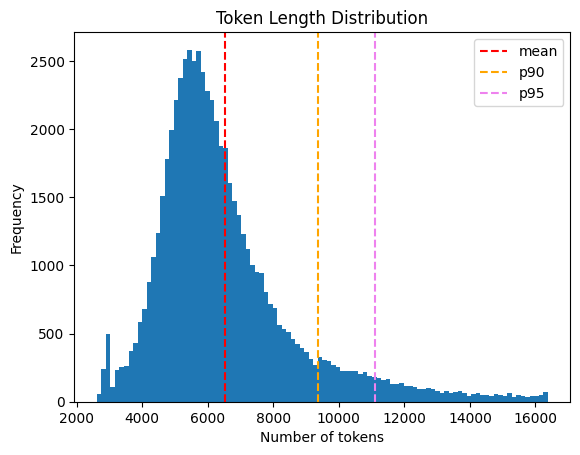

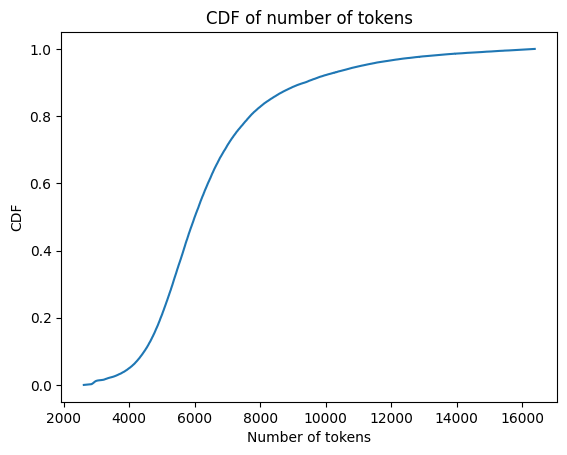

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(lengths, bins=100)

plt.axvline(np.mean(lengths), linestyle="--", label="mean", c='r')
plt.axvline(np.percentile(lengths, 90), linestyle="--", label="p90", c='orange')
plt.axvline(np.percentile(lengths, 95), linestyle="--", label="p95", c='violet')

plt.legend()
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.title("Token Length Distribution")
plt.show()

sorted_lengths = sorted(lengths)
cdf = np.arange(len(sorted_lengths)) / len(sorted_lengths)

plt.figure()
plt.plot(sorted_lengths, cdf)
plt.xlabel("Number of tokens")
plt.ylabel("CDF")
plt.title("CDF of number of tokens")
plt.show()

In [5]:
MODEL_PATH = "/var/essdata/DN_1/storage/home/ttn/models/Qwen3-4B"
DATA_PATH = "/var/essdata/DN_1/storage/home/ttn/data/swe_trajectories/nemotron"
OUTPUT_PATH = "/var/essdata/DN_1/storage/home/ttn/models/qwen3-4b-swe-lora/ft_on_nemotron/chunked_trajectories"

In [6]:
MAX_SEQ_LENGTH = 16384

In [7]:
from unsloth import FastLanguageModel
import torch

# Загрузка модели
print("Загрузка модели...")
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_PATH,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=torch.bfloat16, # тип данных для вычислений
    load_in_4bit=True # если True, то веса модели квантизированы
)

# Настройка LoRA
model = FastLanguageModel.get_peft_model(
    model,
    r=16,  # ранг LoRA
    lora_alpha=32,  # alpha = 2*r для лучшей обучаемости
    lora_dropout=0.0,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",  # attention слои
        "gate_proj", "up_proj", "down_proj",  # MLP слои
    ],
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

Загрузка модели...
==((====))==  Unsloth 2026.2.1: Fast Qwen3 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 PCIe. Num GPUs = 1. Max memory: 79.18 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Unsloth 2026.2.1 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


Изначально я пытался передать в SFTTrainer свой prompt-completion датасет (SFTTrainer поддерживает такой тип датасетов) с параметром completion_only_loss=True (чтобы loss рассчитывался только по completion части) в SFTConfig, но получал ошибку: RuntimeError: Unsloth: You must specify a formatting_func. Видимо, это какая-то проблема совместимости Unsloth и TRL SFT (вот пользователи, также столкнувшиеся с этой проблемой: https://github.com/unslothai/unsloth/issues/3399, https://github.com/unslothai/unsloth/issues/2658)

В официальном TRL SFTTrainer prompt-completion датасеты поддерживаются, а completion_only_loss=True как раз означает считать loss только по completion; но в текущем Unsloth-обёрнутом SFTTrainer есть отдельная логика предобработки, и в репозитории Unsloth есть открытые проблемы именно с prompt-completion датасетами и совместимостью formatting_func/completion_only_loss

Поэтому пришлось самому собрать датасет с input_ids, attention_mask и labels, где -100 в labels стоит на prompt:

In [8]:
def preprocess_batch(batch):
    prompts = batch["prompt"]
    completions = batch["completion"]

    prompt_tok = tokenizer(prompts, add_special_tokens=False)
    completion_tok = tokenizer(completions, add_special_tokens=False)

    input_ids = []
    attention_mask = []
    labels = []

    eos = tokenizer.eos_token_id

    for p_ids, c_ids in zip(prompt_tok["input_ids"], completion_tok["input_ids"]):
        ids = p_ids + c_ids
        lab = [-100] * len(p_ids) + c_ids

        if eos is not None:
            ids = ids + [eos]
            lab = lab + [eos]

        input_ids.append(ids)
        labels.append(lab)
        attention_mask.append([1] * len(ids))

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
    }

tokenized_train = train_chunked_fmt.map(
    preprocess_batch,
    batched=True,
    batch_size=512,
    num_proc=max(1, os.cpu_count() // 2),
    remove_columns=train_chunked_fmt.column_names,
)
tokenized_test = test_chunked_fmt.map(
    preprocess_batch,
    batched=True,
    batch_size=512,
    num_proc=max(1, os.cpu_count() // 2),
    remove_columns=test_chunked_fmt.column_names,
)
tokenized_train.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
tokenized_test.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

`attention_mask.append([1] * len(ids))`: `[1] * len(ids)` означает, что все токены этой последовательности надо учитывать при attention.

Батчи обычно выравниваются по длине `padding`-ом: появляются служебные `pad`-токены. `attention_mask` говорит модели:

* `1` — этот токен участвует в вычислениях
* `0` — это padding, его надо игнорировать

Мы сначала создаём одну последовательность из `prompt + completion`, поэтому для всех реально существующих токенов ставим `1`. Потом в батчах `tokenizer` сам добавит нули на места padding.

In [17]:
sample = tokenized_train[0]
for tok, lab in zip(
    tokenizer.convert_ids_to_tokens(sample["input_ids"]),
    sample["labels"],
):
    print(tok, lab)

<|im_start|> tensor(-100)
system tensor(-100)
Ċ tensor(-100)
You tensor(-100)
Ġare tensor(-100)
ĠOpen tensor(-100)
Hands tensor(-100)
Ġagent tensor(-100)
, tensor(-100)
Ġa tensor(-100)
Ġhelpful tensor(-100)
ĠAI tensor(-100)
Ġassistant tensor(-100)
Ġthat tensor(-100)
Ġcan tensor(-100)
Ġinteract tensor(-100)
Ġwith tensor(-100)
Ġa tensor(-100)
Ġcomputer tensor(-100)
Ġto tensor(-100)
Ġsolve tensor(-100)
Ġtasks tensor(-100)
.ĊĊ tensor(-100)
< tensor(-100)
ROLE tensor(-100)
>Ċ tensor(-100)
Your tensor(-100)
Ġprimary tensor(-100)
Ġrole tensor(-100)
Ġis tensor(-100)
Ġto tensor(-100)
Ġassist tensor(-100)
Ġusers tensor(-100)
Ġby tensor(-100)
Ġexecuting tensor(-100)
Ġcommands tensor(-100)
, tensor(-100)
Ġmodifying tensor(-100)
Ġcode tensor(-100)
, tensor(-100)
Ġand tensor(-100)
Ġsolving tensor(-100)
Ġtechnical tensor(-100)
Ġproblems tensor(-100)
Ġeffectively tensor(-100)
. tensor(-100)
ĠYou tensor(-100)
Ġshould tensor(-100)
Ġbe tensor(-100)
Ġthorough tensor(-100)
, tensor(-100)
Ġmethod tensor(-10

In [9]:
!nvidia-smi

Thu May 14 03:58:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 PCIe               On  |   00000000:01:00.0 Off |                    0 |
| N/A   34C    P0             79W /  350W |   48271MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [10]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model, # Модель, которую мы обучаем. Обучаются только LoRA-параметры, а не вся модель
    train_dataset=tokenized_train, # наш подготовленный датасет для обучения
    eval_dataset=tokenized_test,
    tokenizer=tokenizer, # tokenizer; используется для преобразования текста в токены и паддинга последовательностей (если последовательность < max_seq_length)
    args=SFTConfig( # гиперпараметры обучения
        max_seq_length=MAX_SEQ_LENGTH, # максимальная длина входной последовательности токенов, которую модель может обработать за один раз
        per_device_train_batch_size=8, # Сколько примеров обрабатывается за один шаг в расчёте на один (!) GPU
        gradient_accumulation_steps=8, # Позволяет имитировать большой batch size. Идея: 1 шаг → считаем градиенты, но не обновляем веса
                                       # После 8 шага: градиенты суммируются → обновляем веса.
                                       # Формула эффективного batch effective_batch_size = per_device_train_batch_size * число GPU * gradient_accumulation
                                       # У нас: 8 * 1 (т.к. у нас 1 GPU) * 8 = 64. То есть модель фактически обучается на 64 примерах за шаг обновления.
        warmup_steps=10, # Первые шаги обучения делают плавный разогрев (↑) learning rate (предотвращает нестабильное обучение, уменьшает риск разрушить веса модели)
        num_train_epochs=1,
        #max_steps=60, # Убрать
        learning_rate=2e-4,  # TODO: experiment with different values (try 1e-4 to 5e-4)
        logging_steps=1, # Как часто выводить метрики. 1 = каждый шаг !ИЗМЕНЕНО!
        output_dir=OUTPUT_PATH, # Папка, куда сохраняются: checkpoints, финальная модель, логи
        optim="adamw_8bit", # adamw_8bit — версия AdamW с 8-битными состояниями. Использует библиотеку bitsandbytes. Плюсы: меньше VRAM и почти та же точность
        weight_decay=0.01, # Регуляризация. Добавляет штраф за большие веса: loss = original_loss + λ * ||weights||. Помогает избежать переобучения.
        lr_scheduler_type="linear", # Как меняется learning rate во времени. linear означает: warmup → затем плавное уменьшение
        seed=42,
        report_to="none", # Отключает логирование в сервисы вроде Weights & Biases и TensorBoard
    ),
)

effective_batch_size = (
    trainer.args.per_device_train_batch_size
    * trainer.args.gradient_accumulation_steps
)
steps_per_epoch = len(tokenized_train) // effective_batch_size # сколько шагов в одной эпохе

print(f"Effective batch size: {effective_batch_size}")
print(f"Steps per epoch: {steps_per_epoch}")
print(f"Total training steps: {trainer.args.max_steps}")
print(f"Approximate epochs: {trainer.args.max_steps / steps_per_epoch:.2f}") # max_steps < steps_per_epoch, то модель не проходит весь датасет даже один раз.
print(f"Learning rate: {trainer.args.learning_rate}")

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Effective batch size: 64
Steps per epoch: 962
Total training steps: -1
Approximate epochs: -0.00
Learning rate: 0.0002


Прим.: effective_batch_size специально сделали больше чем при обучении на отфильтрованных траекториях (см. ноутбуки фильтр_v1_... и фильтр_v2_...), чтобы обучение было более стабильным, так как обучаем на чанках, а не на целых траекториях.

In [11]:
# Обучение
print("Начало обучения...")
trainer.train()

# Сохранение модели
print("Сохранение модели...")
model.save_pretrained_merged(
    OUTPUT_PATH,
    tokenizer,
    save_method="merged_16bit", # ВСЕ веса сохраняются в 16-bit формате (не только LoRA адаптеры), 
                                # даже несмотря на то что ещё до дообучения загружали модель в 4-bit формате
                                # (load_in_4bit=True), потому что хранится информация для восстановления
                                # точнее: при расквантовании мы получаем приближённые значения весов 16-bit 
)

print(f"Обучение завершено! Модель сохранена в {OUTPUT_PATH}")

Начало обучения...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 61,585 | Num Epochs = 1 | Total steps = 963
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 8 x 1) = 64
 "-____-"     Trainable parameters = 33,030,144 of 4,055,498,240 (0.81% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,1.109400
2,1.218300
3,1.132300
4,1.052600
5,0.837900
6,0.899200
7,0.929400
8,0.710200
9,0.833200
10,0.709400


Сохранение модели...
Detected local model directory: /var/essdata/DN_1/storage/home/ttn/models/Qwen3-4B
No existing and accessible Hugging Face cache directory found.


...

Copied model-00003-of-00003.safetensors from local model directory


Unsloth: Preparing safetensor model files: 100%|██████████████████████████████████████████| 3/3 [00:14<00:00,  4.97s/it]


Copied model-00002-of-00003.safetensors from local model directory


Unsloth: Merging weights into 16bit: 100%|████████████████████████████████████████████████| 3/3 [00:50<00:00, 16.86s/it]

Unsloth: Merge process complete. Saved to `/var/essdata/DN_1/storage/home/ttn/models/qwen3-4b-swe-lora/ft_on_nemotron/chunked_trajectories`
Обучение завершено! Модель сохранена в /var/essdata/DN_1/storage/home/ttn/models/qwen3-4b-swe-lora/ft_on_nemotron/chunked_trajectories


In [12]:
!ls -lh /var/essdata/DN_1/storage/home/ttn/models/qwen3-4b-swe-lora/ft_on_nemotron/chunked_trajectories/

total 7.6G
-rw-r--r-- 1 root root 1.4K May 14 19:46 README.md
-rw-r--r-- 1 root root  707 May 14 19:46 added_tokens.json
-rw-r--r-- 1 root root 4.1K May 14 19:46 chat_template.jinja
drwxr-xr-x 2 root root 4.0K May 14 12:16 checkpoint-500
drwxr-xr-x 2 root root 4.0K May 14 19:46 checkpoint-963
-rw-r--r-- 1 root root 1.8K May 14 19:46 config.json
-rw-r--r-- 1 root root 1.6M May 14 19:46 merges.txt
-rw-rw-r-- 1 root root 3.7G May 14 19:47 model-00001-of-00003.safetensors
-rw-rw-r-- 1 root root 3.8G May 14 19:47 model-00002-of-00003.safetensors
-rw-rw-r-- 1 root root  96M May 14 19:47 model-00003-of-00003.safetensors
-rw-rw-r-- 1 root root  33K Apr 29  2025 model.safetensors.index.json
-rw-r--r-- 1 root root  613 May 14 19:46 special_tokens_map.json
-rw-r--r-- 1 root root  11M May 14 19:46 tokenizer.json
-rw-r--r-- 1 root root 9.6K May 14 19:46 tokenizer_config.json
-rw-r--r-- 1 root root 2.7M May 14 19:46 vocab.json


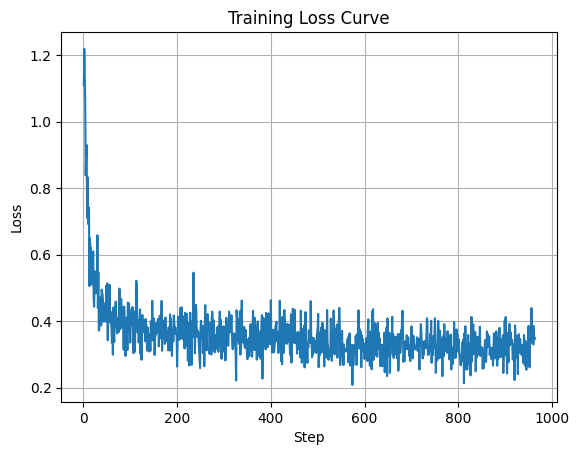

Initial loss: 1.1094
Final loss: 0.3493
Loss reduction: 68.5%

All assertions passed!


In [13]:
import matplotlib.pyplot as plt
log_history = trainer.state.log_history

# Extract the training loss values and corresponding steps from log_history
steps = [entry["step"] for entry in log_history if "loss" in entry]  # TODO
losses = [entry["loss"] for entry in log_history if "loss" in entry]  # TODO

# Plot the training loss curve
plt.figure()
plt.plot(steps, losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

# Assertions
assert len(steps) > 0, "No training steps found in log history"
assert len(losses) > 0, "No loss values found in log history"
assert len(steps) == len(losses), "Steps and losses must have the same length"
assert losses[-1] < losses[0], "Training loss should decrease over time (last < first)"

print(f"Initial loss: {losses[0]:.4f}")
print(f"Final loss: {losses[-1]:.4f}")
print(f"Loss reduction: {(1 - losses[-1] / losses[0]) * 100:.1f}%")
print("\nAll assertions passed!")

In [14]:
print(steps, losses)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 22

In [15]:
log_history

[{'loss': 1.1094,
  'grad_norm': 1.8657121658325195,
  'learning_rate': 0.0,
  'epoch': 0.001039095986491752,
  'step': 1},
 {'loss': 1.2183,
  'grad_norm': 2.25575590133667,
  'learning_rate': 2e-05,
  'epoch': 0.002078191972983504,
  'step': 2},
 {'loss': 1.1323,
  'grad_norm': 2.11716890335083,
  'learning_rate': 4e-05,
  'epoch': 0.0031172879594752565,
  'step': 3},
 {'loss': 1.0526,
  'grad_norm': 1.821970820426941,
  'learning_rate': 6e-05,
  'epoch': 0.004156383945967008,
  'step': 4},
 {'loss': 0.8379,
  'grad_norm': 1.3024402856826782,
  'learning_rate': 8e-05,
  'epoch': 0.005195479932458761,
  'step': 5},
 {'loss': 0.8992,
  'grad_norm': 0.9034294486045837,
  'learning_rate': 0.0001,
  'epoch': 0.006234575918950513,
  'step': 6},
 {'loss': 0.9294,
  'grad_norm': 0.6386945247650146,
  'learning_rate': 0.00012,
  'epoch': 0.007273671905442265,
  'step': 7},
 {'loss': 0.7102,
  'grad_norm': 0.4283158481121063,
  'learning_rate': 0.00014,
  'epoch': 0.008312767891934017,
  'step

In [19]:
# через Unsloth загружаем модель
from unsloth import FastLanguageModel
import torch

model_path = "/var/essdata/DN_1/storage/home/ttn/models/qwen3-4b-swe-lora/ft_on_nemotron/chunked_trajectories"
MAX_SEQ_LENGTH = 16384

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=model_path,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=torch.bfloat16,
    load_in_4bit=False, # тут False! Но если планируется продолжить дообучение с LoRA, то надо поменять на True
)

==((====))==  Unsloth 2026.2.1: Fast Qwen3 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA H100 PCIe. Num GPUs = 1. Max memory: 79.18 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 9.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

In [16]:
!nvidia-smi

Thu May 14 19:58:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.48.01              Driver Version: 590.48.01      CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 PCIe               On  |   00000000:01:00.0 Off |                    0 |
| N/A   32C    P0             78W /  350W |   48271MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## Оценивание качества дообученной модели на test

In [19]:
from trl import SFTTrainer, SFTConfig

trainer = SFTTrainer(
    model=model, # Модель, которую мы обучаем. Обучаются только LoRA-параметры, а не вся модель
    train_dataset=tokenized_train, # наш подготовленный датасет для обучения
    eval_dataset=tokenized_test,
    tokenizer=tokenizer, # tokenizer; используется для преобразования текста в токены и паддинга последовательностей (если последовательность < max_seq_length)
    args=SFTConfig( # гиперпараметры обучения
        max_seq_length=MAX_SEQ_LENGTH, # максимальная длина входной последовательности токенов, которую модель может обработать за один раз
        per_device_train_batch_size=8, # Сколько примеров обрабатывается за один шаг в расчёте на один (!) GPU
        per_device_eval_batch_size=2, # !!! чтобы избежать ошибки OutOfMemory при trainer.evaluate()
        gradient_accumulation_steps=8, # Позволяет имитировать большой batch size. Идея: 1 шаг → считаем градиенты, но не обновляем веса
                                       # После 8 шага: градиенты суммируются → обновляем веса.
                                       # Формула эффективного batch effective_batch_size = per_device_train_batch_size * число GPU * gradient_accumulation
                                       # У нас: 8 * 1 (т.к. у нас 1 GPU) * 8 = 64. То есть модель фактически обучается на 64 примерах за шаг обновления.
        eval_accumulation_steps=4, # !!! чтобы избежать ошибки OutOfMemory при trainer.evaluate()
        warmup_steps=10, # Первые шаги обучения делают плавный разогрев (↑) learning rate (предотвращает нестабильное обучение, уменьшает риск разрушить веса модели)
        num_train_epochs=1,
        #max_steps=60, # Убрать
        learning_rate=2e-4,  # TODO: experiment with different values (try 1e-4 to 5e-4)
        logging_steps=1, # Как часто выводить метрики. 1 = каждый шаг !ИЗМЕНЕНО!
        output_dir=OUTPUT_PATH, # Папка, куда сохраняются: checkpoints, финальная модель, логи
        optim="adamw_8bit", # adamw_8bit — версия AdamW с 8-битными состояниями. Использует библиотеку bitsandbytes. Плюсы: меньше VRAM и почти та же точность
        weight_decay=0.01, # Регуляризация. Добавляет штраф за большие веса: loss = original_loss + λ * ||weights||. Помогает избежать переобучения.
        lr_scheduler_type="linear", # Как меняется learning rate во времени. linear означает: warmup → затем плавное уменьшение
        seed=42,
        report_to="none", # Отключает логирование в сервисы вроде Weights & Biases и TensorBoard
    ),
)

In [20]:
import math

eval_metrics = trainer.evaluate()
print("Eval metrics:", eval_metrics)

if "eval_loss" in eval_metrics:
    print("Perplexity:", math.exp(eval_metrics["eval_loss"]))
    # отвечает на вопрос: насколько хорошо модель предсказывает следующий токен в тестовых траекториях
    # но она не говорит, умеет ли модель правильно выбирать tool call, arguments, и т.п.
    # Пример: Если перплексия равна 100, это означает, что неопределённость модели эквивалентна выбору одного из 100 равновероятных исходов

Eval metrics: {'eval_loss': 0.2898232042789459, 'eval_model_preparation_time': 0.0057, 'eval_runtime': 3207.3342, 'eval_samples_per_second': 1.935, 'eval_steps_per_second': 0.968}
Perplexity: 1.3361912342490339


Eval metrics: {'eval_loss': 0.2898232042789459, 'eval_model_preparation_time': 0.0057, 'eval_runtime': 3207.3342, 'eval_samples_per_second': 1.935, 'eval_steps_per_second': 0.968}
Perplexity: 1.3361912342490339

In [22]:
# Структурный evaluator по tool-call для chunked trajectories (использует prompt как вход, а completion как gold-ответ)

import json
import re
import torch
from copy import deepcopy
from tqdm.auto import tqdm

# Переводим модель в режим инференса
FastLanguageModel.for_inference(model)
model.eval()


def canonical_json_str(x):
    """
    Приводит JSON-строку / dict / list / обычную строку
    к каноническому (нормализованному) виду, чтобы сравнение было стабильным.
    """
    if x is None:
        return ""
    # Если это уже Python-объект, сериализуем канонически
    if isinstance(x, (dict, list)):
        return json.dumps(x, sort_keys=True, ensure_ascii=False, separators=(",", ":"))
    # Если это строка, пробуем распарсить как JSON
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return ""
        try:
            return canonical_json_str(json.loads(s))
        except Exception:
            # Если это не JSON, просто нормализуем пробелы
            return re.sub(r"\s+", " ", s)
    # Всё остальное приводим к строке
    return canonical_json_str(str(x))

def canonical_call_from_gold(call):
    """
    Приводит gold tool_call к виду:
    {
        "name": ...,
        "arguments": ...
    }
    """
    fn = call.get("function", {})
    name = fn.get("name", "")
    args = fn.get("arguments", "")
    return {
        "name": str(name),
        "arguments": canonical_json_str(args),
    }

def canonical_call_from_pred(obj):
    """
    Приводит предсказанный объект к виду:
    {
        "name": ...,
        "arguments": ...
    }

    Поддерживает несколько возможных форматов:
    - {"name": "...", "arguments": "..."}
    - {"function": {"name": "...", "arguments": "..."}}
    - {"tool_calls": [{"function": ...}]}
    """
    if not isinstance(obj, dict):
        return None

    # Иногда модель может вернуть структуру с tool_calls
    if "tool_calls" in obj and isinstance(obj["tool_calls"], list) and obj["tool_calls"]:
        return canonical_call_from_pred(obj["tool_calls"][0])

    # Формат с function внутри
    if "function" in obj and isinstance(obj["function"], dict):
        fn = obj["function"]
        name = fn.get("name", obj.get("name", ""))
        args = fn.get("arguments", obj.get("arguments", ""))
        return {
            "name": str(name),
            "arguments": canonical_json_str(args),
        }

    # Простой формат
    if "name" in obj:
        return {
            "name": str(obj.get("name", "")),
            "arguments": canonical_json_str(obj.get("arguments", "")),
        }

    return None

def balanced_json_candidates(text):
    """
    Достаёт все сбалансированные подстроки вида {...}
    из текста. Это полезно, если модель сгенерировала JSON
    вместе с лишним текстом.
    """
    out = []
    start = None
    depth = 0
    in_str = False
    esc = False

    for i, ch in enumerate(text):
        if start is None:
            if ch == "{":
                start = i
                depth = 1
                in_str = False
                esc = False
            continue

        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == '"':
                in_str = False
            continue

        if ch == '"':
            in_str = True
        elif ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0 and start is not None:
                out.append(text[start:i+1])
                start = None

    return out

def parse_pred_tool_call(text):
    """
    Пытается извлечь из ответа модели предсказанный tool-call.
    Возвращает:
    {
        "name": ...,
        "arguments": ...
    }
    или None, если распарсить не удалось.
    """
    s = text.strip()

    # Сначала пробуем все сбалансированные JSON-фрагменты
    for cand in balanced_json_candidates(s):
        try:
            obj = json.loads(cand)
        except Exception:
            continue
        call = canonical_call_from_pred(obj)
        if call is not None and call["name"]:
            return call

    # запасной поиск имени и arguments через regex
    name = None
    m = re.search(r'"name"\s*:\s*"([^"]+)"', s)
    if m:
        name = m.group(1)

    args = ""
    m2 = re.search(r'"arguments"\s*:\s*(\{.*\}|\[.*\]|"[^"]*"|null)', s, flags=re.S)
    if m2:
        raw_args = m2.group(1)
        try:
            args = canonical_json_str(json.loads(raw_args))
        except Exception:
            args = re.sub(r"\s+", " ", raw_args.strip())
    if name:
        return {"name": name, "arguments": args,}

    return None

def extract_gold_call(completion_messages):
    """
    Извлекает gold tool-call из completion.
    completion состоит из одного assistant-сообщения.
    """
    if not completion_messages:
        return None

    msg = completion_messages[0]
    calls = msg.get("tool_calls") or []

    if calls:
        return canonical_call_from_gold(calls[0])

    # Если вдруг completion без tool_calls, оставим fallback
    # (на практике, скорее всего, сюда попадать не будет)
    return {
        "name": "",
        "arguments": "",
    }


def build_prompt_with_truncation(prompt_messages, max_input_tokens=16384, reserve_new_tokens=256):
    """
    Строит prompt для модели.

    Важно:
    - system всегда сохраняется
    - первый user всегда сохраняется
    - из остальной истории удаляются самые старые сообщения,
      пока prompt + reserve_new_tokens не влезет в контекст
    """
    if len(prompt_messages) < 2:
        prompt = tokenizer.apply_chat_template(
            prompt_messages,
            tokenize=False,
            add_generation_prompt=True
        )
        n_tokens = len(tokenizer(prompt, add_special_tokens=False)["input_ids"])
        return prompt, n_tokens, False

    # Сохраняем system и первый user
    system_msg = deepcopy(prompt_messages[0])
    user_msg = deepcopy(prompt_messages[1])

    # Всё остальное считаем хвостом, который можно обрезать 
    tail = deepcopy(prompt_messages[2:])

    truncated = False

    while True:
        msgs = [system_msg, user_msg] + tail

        prompt = tokenizer.apply_chat_template(
            msgs,
            tokenize=False,
            add_generation_prompt=True
        )
        n_tokens = len(tokenizer(prompt, add_special_tokens=False)["input_ids"])

        # Если prompt помещается с запасом под генерацию — возвращаем
        if n_tokens + reserve_new_tokens <= max_input_tokens:
            return prompt, n_tokens, truncated

        if len(tail) == 0:
            # дальше резать уже нечего
            return prompt, n_tokens, truncated

        # Убираем самый старый шаг из хвоста
        del tail[0]
        truncated = True


def generate_next_assistant_call(prompt_messages, max_new_tokens=256):
    """
    Генерирует следующий assistant-ответ на основе prompt_messages.
    Возвращает:
    - текст генерации
    - был ли prompt укорочен
    - длину prompt в токенах
    """
    prompt, n_tokens, truncated = build_prompt_with_truncation(
        prompt_messages,
        max_input_tokens=16384,
        reserve_new_tokens=max_new_tokens
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.inference_mode():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=0.0,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Отрезаем входные токены и оставляем только сгенерированную часть
    gen_tokens = output[0][inputs["input_ids"].shape[1]:]
    gen_text = tokenizer.decode(gen_tokens, skip_special_tokens=False)
    return gen_text, truncated, n_tokens


# Считаем метрики
def evaluate_structured(test_rows, max_rows=None, max_new_tokens=256):
    total_steps = 0
    name_ok = 0
    args_ok = 0
    joint_ok = 0
    finish_total = 0
    finish_ok = 0
    truncated_steps = 0

    rows = test_rows
    if max_rows is not None:
        rows = rows.select(range(min(max_rows, len(rows))))

    for row in tqdm(rows, desc="Structured eval"):
        prompt_messages = row["prompt"]
        completion_messages = row["completion"]

        gold = extract_gold_call(completion_messages)
        if gold is None:
            continue

        total_steps += 1
        if gold["name"] == "finish":
            finish_total += 1

        pred_text, was_truncated, n_tokens = generate_next_assistant_call(
            prompt_messages,
            max_new_tokens=max_new_tokens
        )
        truncated_steps += int(was_truncated)

        pred = parse_pred_tool_call(pred_text)

        if pred is None:
            continue

        cur_name_ok = (pred["name"] == gold["name"])
        cur_args_ok = (pred["arguments"] == gold["arguments"])
        cur_joint_ok = cur_name_ok and cur_args_ok

        name_ok += int(cur_name_ok)
        args_ok += int(cur_args_ok)
        joint_ok += int(cur_joint_ok)

        if gold["name"] == "finish" and cur_joint_ok:
            finish_ok += 1

    return {
        "steps_total": total_steps,
        "tool_name_accuracy": name_ok / max(total_steps, 1),
        "arguments_exact_match": args_ok / max(total_steps, 1),
        "joint_exact_match": joint_ok / max(total_steps, 1),
        "finish_accuracy": finish_ok / max(finish_total, 1),
        "truncated_steps": truncated_steps,
        "finish_total": finish_total,
    }


# Полный прогон по test может быть долгим (7 ч. 13 мин. у меня получилось).
# Для более быстрой проверки можно поставить max_rows=20 или 30.
struct_metrics = evaluate_structured(test_chunked, max_rows=None, max_new_tokens=256)
print(struct_metrics)

Structured eval:   0%|          | 0/6207 [00:00<?, ?it/s]

{'steps_total': 6207, 'tool_name_accuracy': 0.7017883035282745, 'arguments_exact_match': 0.22893507330433382, 'joint_exact_match': 0.22716288061865636, 'finish_accuracy': 0.0, 'truncated_steps': 5, 'finish_total': 100}


`steps_total` - общее число проверенных шагов (чанков) 

`tool_name_accuracy` - доля шагов (чанков), где модель угадала правильное имя инструмента (tool)

`arguments_exact_match` - доля шагов (чанков), где аргументы совпали точно.
Здесь сравниваются JSON-аргументы tool-call после нормализации. Если хотя бы один ключ, значение или структура отличается, шаг не засчитывается.
Эта метрика отвечает на вопрос: «модель правильно сформировала содержимое вызова?»

`joint_exact_match` - доля шагов (чанков), где совпали и имя инструмента, и аргументы одновременно.

`finish_accuracy` -  доля из этих всех шагов (чанков), где gold-ответом был именно finish, где модель правильно предсказала finish и его аргументы.

`truncated_steps` - сколько шагов (чанков) пришлось оценивать на обрезанном контексте.
То есть prompt не влезал в лимит контекста (16384), и были удалены старые сообщения (сообщения от system и user всегда сохранялись).
Эта метрика показывает, насколько часто оценка шла не по полному диалогу.

`finish_total` - это сколько в тесте встретилось шагов (чанков), где gold-ответом был именно finish